# Every export has a different delimiter

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-engineering-pro/csv-dialect-sniffer/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-engineering-pro/csv-dialect-sniffer/demo.ipynb)

**Day 142 - Data Engineering Pro.**

`csv.Sniffer().sniff()` returns a `Dialect` or raises `csv.Error`. It has no third
answer. So a file that two different dialects parse *perfectly* - every record the
same width, nothing ragged, no exception - gets one of them, silently, and the
other one is never mentioned.

This notebook builds a detector that reports **every** viable dialect and
separates three verdicts: **unambiguous** (one candidate parses cleanly),
**contested** (several do, and the bytes cannot choose), **undetermined** (none do).

Eight mechanisms, each measured on a bundled sample file:

| | mechanism | what it costs |
|---|---|---|
| 1 | two clean parses, different widths | wrong column count, silently |
| 2 | a header row settles the contest | 24 bytes decide it |
| 3 | a successful decode is not evidence | mojibake with no exception |
| 4 | the C1 test, and its exact blind spot | half of accented letters |
| 5 | a BOM inside a column name | `KeyError` on a column that prints fine |
| 6 | `has_header()` answering the undecidable | a year counted as a measurement |
| 7 | sniffing a prefix | at 128 bytes it returns the letter `i` |
| 8 | the wrong quotechar | one record deleted at full width |

Standard library only for the core: `csv`, `io`, `re`, `codecs`, `collections`.


## Setup

Write the three modules to disk, so this runs on Colab with no clone step.

In [1]:
_src = "\"\"\"CSV dialect detection that reports the cases the bytes do not determine.\n\n`csv.Sniffer().sniff()` returns a Dialect or raises. It has no third answer, so a\nfile with two internally-consistent parses gets one of them and no warning. This\nmodule enumerates every viable parse instead of returning one, and separates\nthree verdicts: unambiguous (exactly one candidate parses the file cleanly),\ncontested (several do, and the bytes cannot choose), undetermined (none do).\n\nStandard library only: csv, io, re, codecs, collections, dataclasses.\n\"\"\"\n\nfrom __future__ import annotations\n\nimport codecs\nimport csv\nimport io\nimport re\nfrom collections import Counter\nfrom dataclasses import dataclass, field\nfrom typing import Dict, List, Optional, Sequence, Tuple\n\nDELIMITERS: Tuple[str, ...] = (\",\", \";\", \"\\t\", \"|\", \":\", \" \")\nQUOTECHARS: Tuple[Optional[str], ...] = ('\"', \"'\", None)\n\nENCODINGS: Tuple[str, ...] = (\n    \"utf-8\",\n    \"utf-8-sig\",\n    \"cp1252\",\n    \"latin-1\",\n    \"utf-16\",\n    \"shift_jis\",\n)\n\n# Encodings that map every possible byte to some character, so decoding them\n# never raises. A successful decode is therefore not evidence of anything.\nNEVER_FAIL: frozenset = frozenset({\"latin-1\", \"iso-8859-1\", \"cp437\", \"macroman\"})\n\nBOMS: Tuple[Tuple[bytes, str], ...] = (\n    (codecs.BOM_UTF32_LE, \"utf-32-le\"),\n    (codecs.BOM_UTF32_BE, \"utf-32-be\"),\n    (codecs.BOM_UTF8, \"utf-8-sig\"),\n    (codecs.BOM_UTF16_LE, \"utf-16-le\"),\n    (codecs.BOM_UTF16_BE, \"utf-16-be\"),\n)\n\n_INT = re.compile(r\"^[+-]?\\d+$\")\n_FLOAT = re.compile(r\"^[+-]?(\\d+\\.\\d*|\\.\\d+|\\d+)([eE][+-]?\\d+)?$\")\n_EURO_FLOAT = re.compile(r\"^[+-]?\\d+,\\d+$\")\n_DATE = re.compile(r\"^\\d{4}-\\d{2}-\\d{2}([ T]\\d{2}:\\d{2}(:\\d{2})?)?$\")\n\n\n# --------------------------------------------------------------------------- #\n# parsing\n# --------------------------------------------------------------------------- #\n\n\ndef parse(\n    text: str,\n    delimiter: str,\n    quotechar: Optional[str] = '\"',\n    doublequote: bool = True,\n) -> List[List[str]]:\n    \"\"\"Parse text under one explicit dialect. quotechar=None means no quoting.\"\"\"\n    kwargs: Dict[str, object] = {\"delimiter\": delimiter, \"doublequote\": doublequote}\n    if quotechar is None:\n        kwargs[\"quoting\"] = csv.QUOTE_NONE\n        kwargs[\"quotechar\"] = None\n    else:\n        kwargs[\"quotechar\"] = quotechar\n    stream = io.StringIO(text, newline=\"\")\n    return list(csv.reader(stream, **kwargs))  # type: ignore[arg-type]\n\n\n@dataclass\nclass Shape:\n    \"\"\"What one candidate dialect makes of the file.\"\"\"\n\n    delimiter: str\n    quotechar: Optional[str]\n    records: int\n    counts: Counter\n    modal: int\n    consistency: float\n    ragged: List[int]\n    blanks: int\n    unbalanced_quotes: int\n    viable: bool\n    reason: str\n    truncated_tail: bool = False\n    fields_with_newline: int = 0\n\n    @property\n    def label(self) -> str:\n        d = {\",\": \"comma\", \";\": \"semicolon\", \"\\t\": \"tab\", \"|\": \"pipe\", \":\": \"colon\", \" \": \"space\"}\n        q = \"none\" if self.quotechar is None else repr(self.quotechar)\n        return \"{0} / quote={1}\".format(d.get(self.delimiter, repr(self.delimiter)), q)\n\n\ndef shape_of(\n    text: str,\n    delimiter: str,\n    quotechar: Optional[str] = '\"',\n    min_fields: int = 2,\n) -> Shape:\n    \"\"\"Measure one candidate dialect. Never raises; a failed parse is a Shape.\"\"\"\n    try:\n        rows = parse(text, delimiter, quotechar)\n    except csv.Error as exc:\n        return Shape(delimiter, quotechar, 0, Counter(), 0, 0.0, [], 0, 0, False, str(exc))\n\n    blanks = sum(1 for r in rows if not r or (len(r) == 1 and r[0] == \"\"))\n    body = [r for r in rows if r and not (len(r) == 1 and r[0] == \"\")]\n    counts = Counter(len(r) for r in body)\n    if not body:\n        return Shape(delimiter, quotechar, 0, counts, 0, 0.0, [], blanks, 0, False, \"no records\")\n\n    modal, modal_n = counts.most_common(1)[0]\n    # A file sniffed by prefix ends mid-record. That trailing fragment is an\n    # artefact of the sample, not of the file, so it is excluded and reported -\n    # only when it is the final record, only when the text has no terminator\n    # after it, and only when it is the sole ragged row.\n    truncated = False\n    if (len(body) > 1 and not text.endswith((\"\\n\", \"\\r\"))\n            and len(body[-1]) != modal\n            and sum(1 for r in body if len(r) != modal) == 1):\n        body = body[:-1]\n        counts = Counter(len(r) for r in body)\n        modal, modal_n = counts.most_common(1)[0]\n        truncated = True\n\n    consistency = modal_n / len(body)\n    ragged = [i for i, r in enumerate(body) if len(r) != modal]\n\n    # A field that opens with the quotechar but does not close with it means the\n    # quotechar guess is wrong, even when the field counts happen to line up.\n    unbalanced = 0\n    if quotechar is not None:\n        for row in body:\n            for f in row:\n                s = f.strip()\n                if len(s) > 1 and s.startswith(quotechar) != s.endswith(quotechar):\n                    unbalanced += 1\n\n    if modal < min_fields:\n        viable, reason = False, \"delimiter yields {0} field(s) per record\".format(modal)\n    elif consistency < 1.0:\n        viable, reason = False, \"{0} of {1} records are ragged\".format(len(ragged), len(body))\n    elif unbalanced:\n        viable, reason = False, \"{0} field(s) with an unbalanced quote\".format(unbalanced)\n    else:\n        viable = True\n        reason = \"{0} records x {1} fields, no ragged rows\".format(len(body), modal)\n        if truncated:\n            reason += \" (trailing partial record excluded)\"\n\n    swallowed = sum(1 for r in body for f in r if \"\\n\" in f or \"\\r\" in f)\n\n    return Shape(\n        delimiter, quotechar, len(body), counts, modal, consistency,\n        ragged, blanks, unbalanced, viable, reason, truncated, swallowed,\n    )\n\n\n@dataclass\nclass DelimiterVerdict:\n    status: str  # \"unambiguous\" | \"contested\" | \"undetermined\"\n    viable: List[Shape]\n    all_shapes: List[Shape]\n    preferred: Optional[Shape]\n    reason: str\n    untested: List[str] = field(default_factory=list)\n\n    @property\n    def column_counts(self) -> List[int]:\n        return sorted({s.modal for s in self.viable})\n\n\ndef classify_delimiter(\n    text: str,\n    delimiters: Sequence[str] = DELIMITERS,\n    quotechars: Sequence[Optional[str]] = QUOTECHARS,\n) -> DelimiterVerdict:\n    \"\"\"Enumerate every dialect that parses the file cleanly, then judge.\n\n    Two candidates that differ only in quotechar but produce an identical parse\n    are one candidate: the file contains no quotes, so the setting is untested by\n    it. Distinct field counts are what make a file genuinely contested.\n    \"\"\"\n    shapes = [shape_of(text, d, q) for d in delimiters for q in quotechars]\n    viable = [s for s in shapes if s.viable]\n\n    # Collapse candidates whose parse is indistinguishable on this input. Two\n    # quotechars that produce an identical parse are not two answers - they are\n    # one answer plus a setting this file does not exercise.\n    seen: Dict[Tuple[str, int, int], Shape] = {}\n    collapsed: Dict[Tuple[str, int, int], List[Shape]] = {}\n    for s in sorted(viable, key=lambda s: (s.delimiter, s.quotechar is None)):\n        key = (s.delimiter, s.modal, s.records)\n        seen.setdefault(key, s)\n        collapsed.setdefault(key, []).append(s)\n    distinct = list(seen.values())\n\n    if not distinct:\n        return DelimiterVerdict(\"undetermined\", [], shapes, None,\n                                \"no candidate delimiter parses every record to the same width\")\n\n    # Tie-break heuristics, in order: more columns, then more records (a parse\n    # that merges records has lost rows), then the earlier-listed delimiter.\n    # These are preferences, not evidence, which is why a contested verdict\n    # still reports every candidate.\n    preferred = max(distinct, key=lambda s: (\n        s.modal, s.records,\n        -DELIMITERS.index(s.delimiter) if s.delimiter in DELIMITERS else 0))\n    pkey = (preferred.delimiter, preferred.modal, preferred.records)\n    untested = [\"quote={0}\".format(\"none\" if s.quotechar is None else repr(s.quotechar))\n                for s in collapsed[pkey][1:]]\n\n    if len(distinct) == 1:\n        return DelimiterVerdict(\"unambiguous\", distinct, shapes, preferred,\n                                \"exactly one dialect parses the file cleanly\", untested)\n\n    widths = sorted({s.modal for s in distinct})\n    counts_seen = sorted({s.records for s in distinct})\n    if len(widths) > 1:\n        shape_note = \"implying {0} column(s)\".format(\" or \".join(str(w) for w in widths))\n    else:\n        shape_note = \"all {0} columns wide but {1} record(s) long\".format(\n            widths[0], \" or \".join(str(c) for c in counts_seen))\n    return DelimiterVerdict(\n        \"contested\", distinct, shapes, preferred,\n        \"{0} dialects parse the file cleanly, {1} - the bytes do not choose\".format(\n            len(distinct), shape_note),\n        untested,\n    )\n\n\ndef sniffer_says(text: str) -> Optional[str]:\n    \"\"\"What csv.Sniffer picks, or None if it raises. For comparison only.\"\"\"\n    try:\n        return csv.Sniffer().sniff(text).delimiter\n    except csv.Error:\n        return None\n\n\n# --------------------------------------------------------------------------- #\n# encoding\n# --------------------------------------------------------------------------- #\n\n\n@dataclass\nclass EncodingReport:\n    bom: Optional[str]\n    decodes: Dict[str, bool]\n    texts: Dict[str, str]\n    ruled_out: List[str]\n    not_evidence: List[Tuple[str, str]]\n    plausible: List[str]\n    distinct_texts: int\n    verdict: str\n    reason: str\n\n    @property\n    def survived(self) -> List[str]:\n        return [e for e, ok in self.decodes.items() if ok]\n\n\ndef _not_evidence(enc: str, bom: Optional[str]) -> Optional[Tuple[str, bool]]:\n    \"\"\"Why a successful decode by this encoding proves little, and whether that\n    is disqualifying (the decode is not credible) or merely a caveat (the decode\n    is credible but its success carries almost no information).\"\"\"\n    if enc in NEVER_FAIL:\n        return \"maps all 256 byte values - cannot fail on any input\", True\n    if enc.startswith((\"utf-16\", \"utf-32\")) and bom is None:\n        return \"any byte string of the right length decodes, usually to noise\", True\n    if enc == \"cp1252\":\n        return \"only 5 of 256 byte values are undefined (81 8d 8f 90 9d)\", False\n    return None\n\n\ndef probe_encoding(raw: bytes, encodings: Sequence[str] = ENCODINGS) -> EncodingReport:\n    \"\"\"Report which encodings *can* decode these bytes, and which agree.\n\n    A decode that succeeds is weak evidence at best and no evidence at all for\n    some encodings. The useful signals are which encodings are *ruled out* (a\n    UnicodeDecodeError is a fact about the bytes) and how many distinct strings\n    the survivors produce.\n    \"\"\"\n    bom: Optional[str] = None\n    for marker, name in BOMS:\n        if raw.startswith(marker):\n            bom = name\n            break\n\n    decodes: Dict[str, bool] = {}\n    texts: Dict[str, str] = {}\n    for enc in encodings:\n        try:\n            texts[enc] = raw.decode(enc)\n            decodes[enc] = True\n        except (UnicodeDecodeError, UnicodeError):\n            decodes[enc] = False\n\n    ok = [e for e in encodings if decodes[e]]\n    ruled_out = [e for e in encodings if not decodes[e]]\n    distinct = len({texts[e] for e in ok})\n\n    weak: List[Tuple[str, str]] = []\n    disqualified: set = set()\n    for e in ok:\n        got = _not_evidence(e, bom)\n        if got:\n            why, hard = got\n            weak.append((e, why))\n            if hard:\n                disqualified.add(e)\n\n    # A decode that yields C1 control characters (U+0080-U+009F) is not credible:\n    # real text does not contain them. This is what rules latin-1 out for a\n    # Windows export, where cp1252 puts curly quotes in exactly that byte range.\n    for e in ok:\n        n_c1 = sum(1 for ch in texts[e] if \"\\x80\" <= ch <= \"\\x9f\")\n        if n_c1:\n            weak.append((e, \"decode contains {0} C1 control character(s) - not text\".format(n_c1)))\n            disqualified.add(e)\n\n    plausible = [e for e in ok if e not in disqualified]\n\n    if bom:\n        verdict, reason = bom, \"byte order mark present - this one is not a guess\"\n    elif \"utf-8\" in ok and distinct == 1:\n        verdict, reason = \"utf-8\", \"utf-8 decodes and every surviving encoding agrees\"\n    elif \"utf-8\" in ok:\n        verdict = \"utf-8\"\n        reason = \"utf-8 decodes; {0} encodings decode to {1} different strings\".format(\n            len(ok), distinct)\n    elif len(plausible) == 1:\n        verdict = plausible[0]\n        reason = \"utf-8 ruled out; {0} is the only survivor left after the C1 test\".format(\n            plausible[0])\n    elif ok:\n        verdict = \"undetermined\"\n        reason = \"utf-8 ruled out; {0} candidates decode to {1} different strings\".format(\n            len(ok), distinct)\n    else:\n        verdict, reason = \"undecodable\", \"no candidate encoding decodes these bytes\"\n\n    return EncodingReport(bom, decodes, texts, ruled_out, weak, plausible,\n                          distinct, verdict, reason)\n\n\ndef mojibake_pairs(raw: bytes, a: str = \"utf-8\", b: str = \"latin-1\") -> List[Tuple[str, str]]:\n    \"\"\"Characters where two encodings disagree, aligned by position where possible.\"\"\"\n    try:\n        ta, tb = raw.decode(a), raw.decode(b)\n    except (UnicodeDecodeError, UnicodeError):\n        return []\n    out: List[Tuple[str, str]] = []\n    for wa, wb in zip(re.findall(r\"\\S+\", ta), re.findall(r\"\\S+\", tb)):\n        if wa != wb:\n            out.append((wa, wb))\n    return out\n\n\n# --------------------------------------------------------------------------- #\n# line terminators\n# --------------------------------------------------------------------------- #\n\n\n@dataclass\nclass TerminatorReport:\n    outside: Counter\n    inside: Counter\n    naive_lines: int\n    records: int\n    embedded_fields: int\n    verdict: str\n    reason: str\n\n\ndef scan_terminators(text: str, quotechar: Optional[str] = '\"') -> Tuple[Counter, Counter]:\n    \"\"\"Split newline runs into record terminators and newlines inside a field.\n\n    This needs the quotechar, which is part of the dialect being detected. Line\n    counting and dialect detection are therefore mutually dependent: you cannot\n    count the records to validate a dialect without already having one.\n    \"\"\"\n    outside: Counter = Counter()\n    inside: Counter = Counter()\n    in_quote = False\n    i = 0\n    n = len(text)\n    while i < n:\n        ch = text[i]\n        if quotechar is not None and ch == quotechar:\n            in_quote = not in_quote\n            i += 1\n            continue\n        if ch == \"\\r\":\n            kind = \"\\\\r\\\\n\" if text[i:i + 2] == \"\\r\\n\" else \"\\\\r\"\n            (inside if in_quote else outside)[kind] += 1\n            i += 2 if kind == \"\\\\r\\\\n\" else 1\n            continue\n        if ch == \"\\n\":\n            (inside if in_quote else outside)[\"\\\\n\"] += 1\n            i += 1\n            continue\n        i += 1\n    return outside, inside\n\n\ndef probe_terminator(\n    text: str, delimiter: str = \",\", quotechar: Optional[str] = '\"'\n) -> TerminatorReport:\n    outside, inside = scan_terminators(text, quotechar)\n    naive = len([ln for ln in text.split(\"\\n\") if ln.strip(\"\\r\")])\n    try:\n        rows = [r for r in parse(text, delimiter, quotechar)\n                if r and not (len(r) == 1 and r[0] == \"\")]\n    except csv.Error:\n        rows = []\n    records = len(rows)\n    embedded = sum(1 for r in rows for f in r if \"\\n\" in f or \"\\r\" in f)\n\n    present = [k for k in (\"\\\\r\\\\n\", \"\\\\n\", \"\\\\r\") if outside[k]]\n    if not present:\n        verdict, reason = \"none\", \"no record terminator outside a quoted field\"\n    elif len(present) == 1:\n        verdict = present[0]\n        reason = \"consistent {0} between records\".format(present[0])\n        if verdict == \"\\\\r\":\n            reason += \" - str.split('\\\\n') sees {0} line(s); csv sees {1} records\".format(\n                naive, records)\n    else:\n        verdict = \"mixed\"\n        reason = \"mixed record terminators: \" + \", \".join(\n            \"{0}x{1}\".format(outside[k], k) for k in present)\n    if inside:\n        reason += \"; {0} newline(s) inside quoted fields\".format(sum(inside.values()))\n    return TerminatorReport(outside, inside, naive, records, embedded, verdict, reason)\n\n\n# --------------------------------------------------------------------------- #\n# header\n# --------------------------------------------------------------------------- #\n\n\ndef cell_type(s: str) -> str:\n    s = s.strip()\n    if s == \"\":\n        return \"empty\"\n    if _INT.match(s):\n        return \"int\"\n    if _FLOAT.match(s):\n        return \"float\"\n    if _DATE.match(s):\n        return \"date\"\n    if _EURO_FLOAT.match(s):\n        return \"float,\"\n    return \"text\"\n\n\n@dataclass\nclass HeaderVerdict:\n    status: str  # \"header\" | \"undetermined\"\n    basis: str\n    reason: str\n    sniffer: Optional[bool]\n    first_types: List[str]\n    body_types: List[str]\n    differing: List[int]\n\n\ndef classify_header(rows: Sequence[Sequence[str]], text: Optional[str] = None) -> HeaderVerdict:\n    \"\"\"Decide whether row 0 is a header, and refuse when the file does not say.\n\n    There is exactly one decidable direction. A first row that is text where the\n    body is numeric or dated cannot be a data row for that column, so `header` is\n    provable. The converse is not: a first row whose types match the body is\n    consistent with a data row *and* with a header whose labels happen to be\n    numbers - `2019,2020,2021` is the common case. `csv.Sniffer.has_header()`\n    returns a bool either way, so it answers the undecidable case too.\n    \"\"\"\n    sniffer: Optional[bool] = None\n    if text is not None:\n        try:\n            sniffer = csv.Sniffer().has_header(text)\n        except csv.Error:\n            sniffer = None\n\n    if len(rows) < 2:\n        return HeaderVerdict(\"undetermined\", \"too_short\", \"fewer than two records\",\n                             sniffer, [], [], [])\n\n    first = [cell_type(c) for c in rows[0]]\n    body: List[str] = []\n    for col in range(len(rows[0])):\n        col_types = Counter(cell_type(r[col]) for r in rows[1:] if col < len(r))\n        body.append(col_types.most_common(1)[0][0] if col_types else \"empty\")\n\n    differing = [i for i, (a, b) in enumerate(zip(first, body)) if a != b]\n    header_like = [i for i in differing if first[i] == \"text\" and body[i] != \"text\"]\n\n    if header_like:\n        status, basis = \"header\", \"text_over_nontext\"\n        reason = \"{0} column(s) are text in row 0 and non-text below: {1}\".format(\n            len(header_like), \", \".join(str(i) for i in header_like))\n    elif not differing and set(first) == {\"text\"}:\n        status, basis = \"undetermined\", \"all_text\"\n        reason = \"every column is text in row 0 and below - nothing distinguishes them\"\n    elif not differing:\n        status, basis = \"undetermined\", \"row0_matches_body\"\n        reason = (\"row 0 parses as {0} in every column, same as the body - consistent with a \"\n                  \"data row and with numeric column labels\".format(\"/\".join(sorted(set(first)))))\n    else:\n        status, basis = \"undetermined\", \"mixed\"\n        reason = \"{0} column(s) differ but none are text-over-numeric\".format(len(differing))\n    return HeaderVerdict(status, basis, reason, sniffer, first, body, differing)\n\n\n# --------------------------------------------------------------------------- #\n# sample-size sensitivity\n# --------------------------------------------------------------------------- #\n\n\ndef sample_sensitivity(\n    text: str, sizes: Sequence[int] = (128, 1024, 4096)\n) -> List[Tuple[str, Optional[str], str]]:\n    \"\"\"Sniff prefixes of increasing size. Returns (size label, sniffer pick, our status).\n\n    Sniffing a prefix is the normal thing to do on a large file, and it is why a\n    row 6,000 lines in that contains an embedded delimiter never enters the\n    decision.\n    \"\"\"\n    out: List[Tuple[str, Optional[str], str]] = []\n    for n in list(sizes) + [len(text)]:\n        chunk = text[:n]\n        label = \"all ({0} B)\".format(len(text)) if n >= len(text) else \"{0} B\".format(n)\n        out.append((label, sniffer_says(chunk), classify_delimiter(chunk).status))\n    return out\n\n\n# --------------------------------------------------------------------------- #\n# full audit\n# --------------------------------------------------------------------------- #\n\n\n@dataclass\nclass Audit:\n    name: str\n    size: int\n    encoding: EncodingReport\n    delimiter: DelimiterVerdict\n    terminator: Optional[TerminatorReport]\n    header: Optional[HeaderVerdict]\n    sensitivity: List[Tuple[str, Optional[str], str]]\n    sniffer: Optional[str]\n    notes: List[str] = field(default_factory=list)\n\n    @property\n    def decided(self) -> bool:\n        return (self.delimiter.status == \"unambiguous\"\n                and self.encoding.verdict not in (\"undetermined\", \"undecodable\")\n                and (self.header is None or self.header.status != \"undetermined\"))\n\n\ndef audit(raw: bytes, name: str = \"<bytes>\") -> Audit:\n    \"\"\"Everything the bytes determine, and everything they do not, in one object.\"\"\"\n    enc = probe_encoding(raw)\n    notes: List[str] = []\n\n    text = enc.texts.get(enc.verdict) or enc.texts.get(\"utf-8\") or enc.texts.get(\"latin-1\")\n    if text is None:\n        return Audit(name, len(raw), enc, DelimiterVerdict(\"undetermined\", [], [], None,\n                     \"undecodable\"), None, None, [], None, [\"no encoding decodes these bytes\"])\n\n    if enc.bom == \"utf-8-sig\" and (enc.texts.get(\"utf-8\") or \"\").startswith(\"\ufeff\"):\n        first = (enc.texts[\"utf-8\"].split(\"\\r\")[0].split(\",\")[0].split(\";\")[0])\n        notes.append(\"read as plain 'utf-8' the BOM stays in the first field: {0!r} - which \"\n                     \"prints as {1}\".format(first, first.lstrip(\"\ufeff\")))\n    if enc.not_evidence:\n        notes.append(\"success proves nothing for: \" + \"; \".join(\n            \"{0} ({1})\".format(e, why) for e, why in enc.not_evidence))\n    if enc.distinct_texts > 1:\n        notes.append(\"{0} encodings decode these bytes to {1} different strings, none raising\".format(\n            len(enc.survived), enc.distinct_texts))\n\n    dv = classify_delimiter(text)\n    d = dv.preferred.delimiter if dv.preferred else \",\"\n    q = dv.preferred.quotechar if dv.preferred else '\"'\n    term = probe_terminator(text, d, q)\n    if term.verdict == \"\\\\r\":\n        notes.append(\"bare \\\\r terminator: naive str.split('\\\\n') yields one row\")\n    if term.embedded_fields:\n        notes.append(\"{0} field(s) contain a newline: str.split('\\\\n') counts {1} lines, \"\n                     \"csv counts {2} records\".format(\n                         term.embedded_fields, term.naive_lines, term.records))\n\n    rows = parse(text, d, q) if dv.preferred else []\n    rows = [r for r in rows if r and not (len(r) == 1 and r[0] == \"\")]\n    hdr = classify_header(rows, text) if rows else None\n    if hdr and hdr.status == \"undetermined\" and hdr.sniffer is not None:\n        notes.append(\"csv.Sniffer.has_header() answers {0} where the file does not say\".format(\n            hdr.sniffer))\n\n    sens = sample_sensitivity(text)\n    picks = {p for _, p, _ in sens}\n    if len(picks) > 1:\n        notes.append(\"delimiter pick depends on how much of the file is sampled: \"\n                     + \" -> \".join(repr(p) for _, p, _ in sens))\n\n    if dv.untested:\n        notes.append(\"no field in this file is quoted, so {0} is untested here - it parses \"\n                     \"identically and may not on the next export\".format(\", \".join(dv.untested)))\n    if dv.status == \"contested\":\n        notes.append(\"CONTESTED: \" + dv.reason)\n\n    return Audit(name, len(raw), enc, dv, term, hdr, sens, sniffer_says(text), notes)\n\n\n# --------------------------------------------------------------------------- #\n# sample corpus - ten files, each isolating one mechanism\n# --------------------------------------------------------------------------- #\n\n\ndef sample_files() -> Dict[str, bytes]:\n    \"\"\"Bytes, not strings: the encoding cases are only real as bytes.\"\"\"\n    files: Dict[str, bytes] = {}\n\n    # 1. Two internally-consistent parses, different widths, no header to break the tie.\n    files[\"sensor.csv\"] = (\n        \"2024-01-01;12;1,50;18,00\\r\\n\"\n        \"2024-01-02;8;2,25;18,00\\r\\n\"\n        \"2024-01-03;15;1,20;18,00\\r\\n\"\n        \"2024-01-04;9;2,00;18,00\\r\\n\"\n    ).encode(\"utf-8\")\n\n    # 2. The same export with a header: the header breaks the tie.\n    files[\"sales_eu.csv\"] = (\n        \"day;units;price;total\\r\\n\"\n        \"2024-01-01;12;1,50;18,00\\r\\n\"\n        \"2024-01-02;8;2,25;18,00\\r\\n\"\n        \"2024-01-03;15;1,20;18,00\\r\\n\"\n    ).encode(\"utf-8\")\n\n    # 3. cp1252 smart quotes + umlaut: utf-8 is provably ruled out.\n    files[\"cp1252.csv\"] = (\n        \"id,note\\r\\n\"\n        \"1,\\x93Ausf\\xfchrung\\x94 abgeschlossen\\r\\n\"\n        \"2,Gr\\xf6\\xdfe ge\\xe4ndert \\x96 ok\\r\\n\"\n    )\n    files[\"cp1252.csv\"] = files[\"cp1252.csv\"].encode(\"latin-1\")\n\n    # 4. utf-8 bytes that latin-1 will happily mis-decode. Nothing raises.\n    files[\"utf8_umlaut.csv\"] = \"id,note\\r\\n1,Ausf\u00fchrung\\r\\n2,Gr\u00f6\u00dfe\\r\\n\".encode(\"utf-8\")\n\n    # 5. UTF-8 BOM: the first column name gains an invisible character.\n    files[\"bom.csv\"] = \"\ufeffid,name,amount\\r\\n1,Widget,10\\r\\n2,Bolt,20\\r\\n\".encode(\"utf-8\")\n\n    # 6. Numeric header names - Sniffer's type heuristic has nothing to hold.\n    files[\"years.csv\"] = (\n        \"2019,2020,2021\\r\\n\" \"120,140,150\\r\\n\" \"90,110,130\\r\\n\"\n    ).encode(\"utf-8\")\n\n    # 7. All text, no header: undecidable by construction.\n    files[\"alltext.csv\"] = (\n        \"north,widget,blue\\r\\n\" \"south,bolt,red\\r\\n\" \"east,nut,green\\r\\n\"\n    ).encode(\"utf-8\")\n\n    # 8. Bare \\r terminator (classic Mac / some Excel exports).\n    files[\"mac.csv\"] = (\"id,name\\r\" \"1,Widget\\r\" \"2,Bolt\\r\").encode(\"utf-8\")\n\n    # 9. Quoted delimiter and quoted newline: physical lines != records.\n    files[\"quoted.csv\"] = (\n        'id,address,note\\r\\n'\n        '1,\"12 High St, Apt 4\",\"line one\\nline two\"\\r\\n'\n        '2,\"9 Mill Rd\",ok\\r\\n'\n    ).encode(\"utf-8\")\n\n    # 10. Dutch surnames begin with an apostrophe. Read as a quotechar, the\n    #     apostrophe opens a field that runs to the next one - two records\n    #     become one, and the column count does not change.\n    files[\"dutch.csv\"] = (\n        \"id,name,town\\r\\n\"\n        \"1,'t Hooft,Delft\\r\\n\"\n        \"2,'s Gravesande,Leiden\\r\\n\"\n        \"3,de Vries,Utrecht\\r\\n\"\n    ).encode(\"utf-8\")\n\n    # 11. Clean for the first kilobyte, then a row with an embedded delimiter.\n    head = \"id,name,amount\\r\\n\" + \"\".join(\n        \"{0},Widget {0},{1}\\r\\n\".format(i, i * 10) for i in range(1, 61))\n    files[\"late.csv\"] = (head + '61,\"Bolt, hex\",610\\r\\n62,Nut,620\\r\\n').encode(\"utf-8\")\n\n    return files\n\n\ndef tab_or_space() -> bytes:\n    \"\"\"A column-aligned report: tab and space both parse, to different widths.\"\"\"\n    return (\n        \"region\\tunits\\tprice\\r\\n\"\n        \"north\\t12\\t1.50\\r\\n\"\n        \"south\\t8\\t2.25\\r\\n\"\n    ).encode(\"utf-8\")\n"
from pathlib import Path
Path("sniff.py").write_text(_src)
print("wrote sniff.py:", len(_src.splitlines()), "lines")


wrote sniff.py: 703 lines


In [2]:
_src = "\"\"\"Seven experiments, each isolating one way dialect detection returns a wrong\nanswer without raising. Every table in README.md is printed by this file.\n\n    python3 evidence.py\n\"\"\"\n\nfrom __future__ import annotations\n\nimport csv\nfrom typing import List, Optional, Sequence\n\nimport sniff\n\nRULE = \"-\" * 78\n\n\ndef head(n: int, title: str) -> None:\n    print(\"\\n\" + \"=\" * 78)\n    print(\"{0}. {1}\".format(n, title))\n    print(\"=\" * 78)\n\n\ndef table(headers: Sequence[str], rows: Sequence[Sequence[object]], widths: Sequence[int]) -> None:\n    fmt = \"  \".join(\"{{{0}:<{1}}}\".format(i, w) for i, w in enumerate(widths))\n    print(fmt.format(*headers))\n    print(RULE)\n    for r in rows:\n        print(fmt.format(*[str(c) for c in r]))\n    print(RULE)\n\n\n# --------------------------------------------------------------------------- #\n\n\ndef exp1_contested() -> None:\n    head(1, \"Two parses, both clean, different widths - and Sniffer picks one\")\n    raw = sniff.sample_files()[\"sensor.csv\"]\n    text = raw.decode(\"utf-8\")\n    print(\"\\nsensor.csv, an export with no header row:\\n\")\n    for line in text.splitlines():\n        print(\"    \" + line)\n\n    v = sniff.classify_delimiter(text)\n    rows: List[List[object]] = []\n    for s in sorted(v.all_shapes, key=lambda s: (s.delimiter, str(s.quotechar))):\n        if s.quotechar != '\"':\n            continue\n        rows.append([s.label.split(\" /\")[0], s.modal, \"{0:.0%}\".format(s.consistency),\n                     \"yes\" if s.viable else \"no\", s.reason])\n    print()\n    table([\"delimiter\", \"fields\", \"consistent\", \"viable\", \"why\"],\n          rows, [12, 6, 10, 6, 40])\n\n    print(\"\\nverdict: {0} - {1}\".format(v.status.upper(), v.reason))\n    print(\"csv.Sniffer().sniff() picks: {0!r}  ->  {1} columns\".format(\n        sniff.sniffer_says(text),\n        sniff.shape_of(text, sniff.sniffer_says(text) or \",\").modal))\n    print(\"the file was written by a German ERP: the delimiter is ';' and '1,50' is one and a half.\")\n    print(\"\\nRead the comma way, row 1 is:\")\n    print(\"   \", sniff.parse(text, \",\")[0])\n    print(\"Read the semicolon way, row 1 is:\")\n    print(\"   \", sniff.parse(text, \";\")[0])\n    print(\"\\nBoth are 100% consistent across all 4 records. Nothing is ragged. Nothing raises.\")\n\n\ndef exp2_header_breaks_tie() -> None:\n    head(2, \"A header row is 24 bytes and it settles the question\")\n    files = sniff.sample_files()\n    for name in (\"sensor.csv\", \"sales_eu.csv\"):\n        text = files[name].decode(\"utf-8\")\n        v = sniff.classify_delimiter(text)\n        print(\"\\n{0}  ({1} B)\".format(name, len(files[name])))\n        print(\"  first line : \" + text.splitlines()[0])\n        print(\"  status     : {0}\".format(v.status))\n        print(\"  viable     : \" + \", \".join(\n            \"{0} -> {1} cols\".format(s.label.split(\" /\")[0], s.modal) for s in v.viable))\n        print(\"  sniffer    : {0!r}\".format(sniff.sniffer_says(text)))\n    print(\"\\nThe header contains no commas, so the comma parse makes it a single field while the\")\n    print(\"body has three - ragged, and therefore ruled out. The same data without the header is\")\n    print(\"undecidable. Writing a header row is a data-quality control, not a formatting habit.\")\n\n\ndef exp3_encoding() -> None:\n    head(3, \"A successful decode is not evidence; a failed one is\")\n    files = sniff.sample_files()\n    for name in (\"cp1252.csv\", \"utf8_umlaut.csv\"):\n        raw = files[name]\n        r = sniff.probe_encoding(raw)\n        print(\"\\n{0}  ({1} B)   verdict: {2}\".format(name, len(raw), r.verdict))\n        print(\"  \" + r.reason)\n        rows: List[List[object]] = []\n        for enc in sniff.ENCODINGS:\n            ok = r.decodes[enc]\n            sample = \"\"\n            if ok:\n                line = r.texts[enc].splitlines()[1] if len(r.texts[enc].splitlines()) > 1 else \"\"\n                sample = line[:34]\n            why = next((w for e, w in r.not_evidence if e == enc), \"\")\n            rows.append([enc, \"yes\" if ok else \"NO\",\n                         repr(sample)[:36] if ok else \"-\",\n                         why[:30]])\n        table([\"encoding\", \"decodes\", \"row 1 as decoded\", \"success proves nothing because\"],\n              rows, [10, 7, 36, 30])\n\n    print(\"\\nThe C1 test is the discriminator that works: bytes 0x80-0x9f are printable characters\")\n    print(\"in cp1252 and undefined control codes in latin-1, and text does not contain control\")\n    print(\"codes. Its coverage in the other direction - utf-8 bytes read as latin-1 - is exactly\")\n    print(\"half, and the half it catches is not the half you would guess:\")\n    letters = [chr(c) for c in range(0xC0, 0x180)]\n    caught = [c for c in letters if any(0x80 <= b <= 0x9F for b in c.encode(\"utf-8\")[1:])]\n    print(\"    {0} of {1} accented Latin letters encode with a continuation byte in 0x80-0x9f\".format(\n        len(caught), len(letters)))\n    print(\"    caught : \" + \"\".join(caught[:16]))\n    print(\"    missed : \" + \"\".join([c for c in letters if c not in caught][:16]))\n    print(\"\\nA code point's second utf-8 byte is 0x80 | (cp & 0x3f), so U+00C0-U+00DF land inside\")\n    print(\"the C1 range and U+00E0-U+00FF do not. Upper case is caught, lower case is not:\")\n    for a, b in sniff.mojibake_pairs(files[\"utf8_umlaut.csv\"], \"utf-8\", \"latin-1\"):\n        c1 = sum(1 for ch in b if \"\\x80\" <= ch <= \"\\x9f\")\n        print(\"    utf-8 {0:<14} latin-1 {1:<20} C1 chars: {2}  {3}\".format(\n            repr(a), repr(b), c1, \"DISQUALIFIED\" if c1 else \"passes, and is wrong\"))\n    print(\"\\nOne caught character anywhere in the file disqualifies latin-1 for the whole file, so\")\n    print(\"on real prose the test usually fires. On a file of lower-case-only names it does not.\")\n\n\ndef exp4_bom() -> None:\n    head(4, \"The BOM that becomes part of a column name\")\n    raw = sniff.sample_files()[\"bom.csv\"]\n    plain = raw.decode(\"utf-8\")\n    stripped = raw.decode(\"utf-8-sig\")\n    rows = sniff.parse(plain, \",\")\n    rows_s = sniff.parse(stripped, \",\")\n    print(\"\\nfirst three bytes : {0!r}\".format(raw[:3]))\n    print(\"read as 'utf-8'      : header = {0!r}\".format(rows[0]))\n    print(\"read as 'utf-8-sig'  : header = {0!r}\".format(rows_s[0]))\n    print(\"\\nprinted, they are identical:\")\n    print(\"    utf-8      -> \" + \"|\".join(rows[0]))\n    print(\"    utf-8-sig  -> \" + \"|\".join(rows_s[0]))\n    print(\"\\nand compared, they are not:\")\n    print(\"    rows[0][0] == 'id'  ->  {0}\".format(rows[0][0] == \"id\"))\n    print(\"    len(rows[0][0])     ->  {0}   (for a two-character name)\".format(len(rows[0][0])))\n    print(\"\\nSo df['id'] raises KeyError on a column that prints as id, in a file that opened\")\n    print(\"cleanly, on a dashboard that worked yesterday against an export from a different tool.\")\n\n\ndef exp5_header_undecidable() -> None:\n    head(5, \"has_header() returns a bool for a question the file does not answer\")\n    files = sniff.sample_files()\n    rows: List[List[object]] = []\n    for name in (\"sales_eu.csv\", \"years.csv\", \"alltext.csv\", \"sensor.csv\"):\n        text = files[name].decode(\"utf-8\")\n        v = sniff.classify_delimiter(text)\n        d = v.preferred.delimiter if v.preferred else \",\"\n        parsed = [r for r in sniff.parse(text, d) if r]\n        h = sniff.classify_header(parsed, text)\n        rows.append([name, text.splitlines()[0][:26], h.sniffer, h.status, h.basis])\n    table([\"file\", \"first line\", \"Sniffer\", \"this module\", \"basis\"],\n          rows, [14, 26, 8, 13, 18])\n    print(\"\\nyears.csv is the case that matters. Its first row is 2019,2020,2021 - column labels\")\n    print(\"that are integers, so every type test sees a numeric row over numeric rows and\")\n    print(\"concludes no header. alltext.csv is the mirror image: three text rows, and the first\")\n    print(\"one is data. Sniffer answers False for both, and it is wrong about one of them; which\")\n    print(\"one is not recoverable from the file.\")\n    print(\"\\nWhat the two answers cost, on years.csv:\")\n    parsed = sniff.parse(files[\"years.csv\"].decode(\"utf-8\"), \",\")\n    print(\"    header=0    -> columns {0}, {1} data rows, sum of col 0 = {2}\".format(\n        parsed[0], len(parsed) - 1, sum(int(r[0]) for r in parsed[1:])))\n    print(\"    header=None -> columns [0, 1, 2], {0} data rows, sum of col 0 = {1}\".format(\n        len(parsed), sum(int(r[0]) for r in parsed)))\n    print(\"    a 2019 that is counted as a measurement inflates column 0 by {0}.\".format(\n        int(parsed[0][0])))\n\n\ndef exp6_sample_size() -> None:\n    head(6, \"Sniffing a prefix, and the letter i\")\n    text = sniff.sample_files()[\"late.csv\"].decode(\"utf-8\")\n    rows: List[List[object]] = []\n    for size in (64, 128, 256, 1024, len(text)):\n        chunk = text[:size]\n        label = \"all ({0} B)\".format(len(text)) if size >= len(text) else \"{0} B\".format(size)\n        pick = sniff.sniffer_says(chunk)\n        v = sniff.classify_delimiter(chunk)\n        rows.append([label, repr(pick) if pick else \"raises\",\n                     sniff.shape_of(chunk, pick).modal if pick else \"-\",\n                     v.status, v.preferred.modal if v.preferred else \"-\"])\n    table([\"sample\", \"Sniffer picks\", \"its cols\", \"this module\", \"its cols\"],\n          rows, [14, 14, 9, 14, 9])\n    print(\"\\nAt 64 bytes Sniffer raises. At 128 bytes it returns {0!r} - not a delimiter it was\".format(\n        sniff.sniffer_says(text[:128])))\n    print(\"offered, but a letter from the word 'Widget', because _guess_delimiter falls through to\")\n    print(\"any character with a consistent per-line frequency when no preferred candidate has one.\")\n    print(\"It does not raise: it returns a Dialect whose delimiter is 'i', and a 2-column frame.\")\n    print(\"\\nThe file is 1,101 B. A 1 KB sniff sample - the common default - stops at record 60.\")\n    print(\"Record 61 is the only quoted field in the file:\")\n    print(\"    \" + [ln for ln in text.splitlines() if '\"' in ln][0])\n    print(\"So the sample that chose the dialect never saw the row the dialect exists for.\")\n\n\ndef exp7_line_counting() -> None:\n    head(7, \"Counting records needs the dialect; validating the dialect needs the count\")\n    files = sniff.sample_files()\n    rows: List[List[object]] = []\n    for name in (\"quoted.csv\", \"mac.csv\", \"sales_eu.csv\"):\n        text = files[name].decode(\"utf-8\")\n        v = sniff.classify_delimiter(text)\n        d = v.preferred.delimiter if v.preferred else \",\"\n        t = sniff.probe_terminator(text, d)\n        rows.append([name, t.verdict, t.naive_lines, t.records,\n                     sum(t.inside.values()), t.records - t.naive_lines])\n    table([\"file\", \"terminator\", \"split('\\\\n')\", \"csv records\", \"nl in field\", \"delta\"],\n          rows, [14, 11, 12, 12, 12, 6])\n    print(\"\\nmac.csv uses a bare \\\\r, so str.split('\\\\n') returns one line for three records and\")\n    print(\"wc -l reports 0. quoted.csv has a newline inside a quoted address, so the naive count\")\n    print(\"is one too many. Both are off, in opposite directions, and neither raises.\")\n    print(\"\\nThe circularity is the point: to know that a newline is inside a field you must know\")\n    print(\"the quotechar, which is part of the dialect you are trying to detect. scan_terminators()\")\n    print(\"takes the quotechar as an argument rather than pretending it can be inferred first.\")\n\n    text = files[\"quoted.csv\"].decode(\"utf-8\")\n    print(\"\\nAnd the setting this file does exercise, versus one it does not:\")\n    for name in (\"quoted.csv\", \"sales_eu.csv\"):\n        v = sniff.classify_delimiter(files[name].decode(\"utf-8\"))\n        print(\"    {0:<14} untested: {1}\".format(\n            name, \", \".join(v.untested) if v.untested else \"none - the file has quoted fields\"))\n\n\ndef exp8_quotechar() -> None:\n    head(8, \"The wrong quotechar loses a row without changing the column count\")\n    files = sniff.sample_files()\n    text = files[\"dutch.csv\"].decode(\"utf-8\")\n    print(\"\\ndutch.csv - Dutch surnames begin with an apostrophe:\\n\")\n    for line in text.splitlines():\n        print(\"    \" + line)\n\n    print('\\nquotechar=\\'\"\\' (4 records):')\n    for r in sniff.parse(text, \",\", '\"'):\n        print(\"    \" + repr(r))\n    print(\"\\nquotechar=\\\"'\\\" (3 records):\")\n    for r in sniff.parse(text, \",\", \"'\"):\n        print(\"    \" + repr(r))\n\n    v = sniff.classify_delimiter(text)\n    rows: List[List[object]] = []\n    for s in v.viable:\n        rows.append([s.label, s.records, s.modal, \"{0:.0%}\".format(s.consistency),\n                     s.fields_with_newline])\n    print()\n    table([\"dialect\", \"records\", \"fields\", \"consistent\", \"nl in field\"], rows, [22, 9, 8, 11, 12])\n    print(\"\\nverdict: {0} - {1}\".format(v.status.upper(), v.reason))\n    print(\"\\nBoth parses are 3 columns wide and 100% consistent. One of them has three records\")\n    print(\"where the file has four: the apostrophe on 't Hooft opened a quoted field that ran to\")\n    print(\"the apostrophe on 's Gravesande, absorbing the record terminator between them. Every\")\n    print(\"check that watches the column count passes. The row is simply gone, and the two names\")\n    print(\"it merged are now one field containing a newline - which is why fields_with_newline is\")\n    print(\"the signal, and why the tie-break prefers the parse that keeps more records.\")\n\n\ndef ledger() -> None:\n    head(9, \"The ledger\")\n    files = sniff.sample_files()\n    rows: List[List[object]] = [\n        [\"two clean parses, 3 vs 4 cols\", \"sensor.csv\", \"wrong column count\", \"silent\"],\n        [\"utf-8 read as latin-1\", \"utf8_umlaut.csv\", \"Ausf\u00c3\u00bchrung in every row\", \"silent\"],\n        [\"latin-1 read for a cp1252 file\", \"cp1252.csv\", \"C1 controls in the text\", \"silent\"],\n        [\"BOM kept as a name character\", \"bom.csv\", \"KeyError on a visible column\", \"raises late\"],\n        [\"numeric header read as data\", \"years.csv\", \"col 0 inflated by 2019\", \"silent\"],\n        [\"text data row read as header\", \"alltext.csv\", \"one row lost, names wrong\", \"silent\"],\n        [\"apostrophe read as a quotechar\", \"dutch.csv\", \"1 of 4 records merged away\", \"silent\"],\n        [\"prefix sniff picks 'i'\", \"late.csv\", \"1-column frame\", \"silent\"],\n        [\"bare \\\\r line ending\", \"mac.csv\", \"3 records counted as 1\", \"silent\"],\n        [\"newline inside a quoted field\", \"quoted.csv\", \"line count one too high\", \"silent\"],\n    ]\n    table([\"failure mode\", \"sample\", \"effect\", \"raises?\"], rows, [32, 16, 26, 10])\n    audits = {n: sniff.audit(r, n) for n, r in files.items()}\n    undecided = [n for n, a in audits.items() if not a.decided]\n    print(\"\\n{0} of the {1} sample files are fully determined by their own bytes.\".format(\n        len(files) - len(undecided), len(files)))\n    print(\"The other {0} are not: {1}\".format(len(undecided), \", \".join(sorted(undecided))))\n    print(\"Nine of the ten failure modes above produce a plausible answer with no exception, and\")\n    print(\"all ten are reproducible - re-running the load gives the same wrong number, so a\")\n    print(\"reconciliation against yesterday agrees.\")\n\n\ndef main() -> None:\n    exp1_contested()\n    exp2_header_breaks_tie()\n    exp3_encoding()\n    exp4_bom()\n    exp5_header_undecidable()\n    exp6_sample_size()\n    exp7_line_counting()\n    exp8_quotechar()\n    ledger()\n    print()\n\n\nif __name__ == \"__main__\":\n    main()\n"
from pathlib import Path
Path("evidence.py").write_text(_src)
print("wrote evidence.py:", len(_src.splitlines()), "lines")


wrote evidence.py: 297 lines


In [3]:
_src = "\"\"\"Six-panel audit figure. Every number is computed from sniff.py, not typed in.\n\n    python3 make_chart.py            -> sniff_audit.png\n    python3 make_chart.py nb         -> sniff_audit_nb.png (notebook variant)\n\"\"\"\n\nfrom __future__ import annotations\n\nimport sys\nfrom typing import Dict, List\n\nimport matplotlib\nif __name__ == \"__main__\":  # importing this from a notebook must not steal the backend\n    matplotlib.use(\"Agg\")\nimport matplotlib.pyplot as plt\nimport numpy as np\n\nimport sniff\n\nINK = \"#1d2330\"\nMUTED = \"#8b93a7\"\nOK = \"#2f8f6b\"\nWARN = \"#d98324\"\nBAD = \"#b8434f\"\nGRID = \"#e3e6ee\"\n\nFILES = sniff.sample_files()\nTEXT = {n: r.decode(\"utf-8\", errors=\"replace\") for n, r in FILES.items()}\n\n\ndef style(ax: plt.Axes, title: str, sub: str = \"\", integer_y: bool = False) -> None:\n    ax.set_title(title, fontsize=10.5, fontweight=\"bold\", color=INK, loc=\"left\", pad=30)\n    if sub:\n        ax.text(0, 1.018, sub, transform=ax.transAxes, fontsize=8, color=MUTED, va=\"bottom\")\n    if integer_y:\n        ax.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(integer=True))\n    for s in (\"top\", \"right\"):\n        ax.spines[s].set_visible(False)\n    for s in (\"left\", \"bottom\"):\n        ax.spines[s].set_color(GRID)\n    ax.tick_params(labelsize=8, colors=MUTED, length=3)\n    ax.grid(axis=\"y\", color=GRID, lw=0.7)\n    ax.set_axisbelow(True)\n\n\n# --------------------------------------------------------------------------- #\n\n\ndef panel_candidates(ax: plt.Axes) -> None:\n    v = sniff.classify_delimiter(TEXT[\"sensor.csv\"])\n    shapes = [s for s in v.all_shapes if s.quotechar == '\"']\n    shapes.sort(key=lambda s: -s.modal)\n    labels = [s.label.split(\" /\")[0] for s in shapes]\n    vals = [s.modal for s in shapes]\n    colors = [BAD if s.viable else MUTED for s in shapes]\n    ax.bar(range(len(vals)), vals, color=colors, width=0.62)\n    ax.set_xticks(range(len(vals)))\n    ax.set_xticklabels(labels, rotation=30, ha=\"right\")\n    ax.set_ylabel(\"fields per record\", fontsize=8, color=MUTED)\n    for i, s in enumerate(shapes):\n        if s.viable:\n            ax.text(i, s.modal + 0.12, \"clean\", ha=\"center\", fontsize=7.5,\n                    color=BAD, fontweight=\"bold\")\n    style(ax, \"1  sensor.csv: two clean parses\",\n          \"red = every record the same width. 3 columns or 4, and no exception either way\",\n          integer_y=True)\n\n\ndef panel_header_tie(ax: plt.Axes) -> None:\n    names = [\"sensor.csv\\n(no header)\", \"sales_eu.csv\\n(header row)\"]\n    counts = []\n    for n in (\"sensor.csv\", \"sales_eu.csv\"):\n        counts.append(len(sniff.classify_delimiter(TEXT[n]).viable))\n    colors = [BAD if c > 1 else OK for c in counts]\n    ax.bar(range(2), counts, color=colors, width=0.5)\n    ax.set_xticks(range(2))\n    ax.set_xticklabels(names)\n    ax.set_yticks([0, 1, 2])\n    ax.set_ylabel(\"viable dialects\", fontsize=8, color=MUTED)\n    for i, c in enumerate(counts):\n        ax.text(i, c + 0.05, \"contested\" if c > 1 else \"unambiguous\", ha=\"center\",\n                fontsize=7.5, color=colors[i], fontweight=\"bold\")\n    style(ax, \"2  A header row decides it\",\n          \"same data, 24 more bytes: the comma parse becomes ragged and drops out\")\n\n\ndef panel_encoding(ax: plt.Axes) -> None:\n    order = [\"cp1252.csv\", \"utf8_umlaut.csv\", \"bom.csv\", \"sensor.csv\"]\n    decodes, credible = [], []\n    for n in order:\n        r = sniff.probe_encoding(FILES[n])\n        decodes.append(len(r.survived))\n        credible.append(len(r.plausible))\n    x = np.arange(len(order))\n    ax.bar(x - 0.19, decodes, width=0.36, color=MUTED, label=\"decode without raising\")\n    ax.bar(x + 0.19, credible, width=0.36, color=OK, label=\"credible after the C1 test\")\n    ax.set_xticks(x)\n    ax.set_xticklabels([n.replace(\".csv\", \"\") for n in order], rotation=20, ha=\"right\")\n    ax.set_ylabel(\"encodings (of 6 tried)\", fontsize=8, color=MUTED)\n    ax.legend(fontsize=7, frameon=False, loc=\"upper right\")\n    style(ax, \"3  Decoding proves less than it looks\",\n          \"latin-1 cannot fail on any input, so its success is never evidence\")\n\n\ndef panel_c1_coverage(ax: plt.Axes) -> None:\n    letters = [chr(c) for c in range(0xC0, 0x180)]\n    caught = sum(1 for c in letters\n                 if any(0x80 <= b <= 0x9F for b in c.encode(\"utf-8\")[1:]))\n    missed = len(letters) - caught\n    ax.barh([1, 0], [caught, missed], color=[OK, BAD], height=0.5)\n    ax.set_yticks([1, 0])\n    ax.set_yticklabels([\"caught\\n(U+00C0-DF, upper case)\", \"missed\\n(U+00E0-FF, lower case)\"],\n                       fontsize=8)\n    ax.set_xlabel(\"accented Latin letters\", fontsize=8, color=MUTED)\n    ax.text(caught - 4, 1, str(caught), va=\"center\", ha=\"right\", color=\"white\",\n            fontsize=9, fontweight=\"bold\")\n    ax.text(missed - 4, 0, str(missed), va=\"center\", ha=\"right\", color=\"white\",\n            fontsize=9, fontweight=\"bold\")\n    ax.grid(axis=\"x\", color=GRID, lw=0.7)\n    style(ax, \"4  The C1 test is exactly half blind\",\n          \"second utf-8 byte is 0x80|(cp & 0x3f), so only half land in 0x80-0x9f\")\n    ax.grid(axis=\"y\", visible=False)\n\n\ndef panel_sample_size(ax: plt.Axes) -> None:\n    text = TEXT[\"late.csv\"]\n    sizes = [64, 128, 256, 512, 1024, len(text)]\n    cols: List[float] = []\n    labels: List[str] = []\n    for n in sizes:\n        pick = sniff.sniffer_says(text[:n])\n        cols.append(sniff.shape_of(text[:n], pick).modal if pick else 0)\n        labels.append(\"{0}\\n{1}\".format(n, repr(pick) if pick else \"raises\"))\n    colors = [OK if c == 3 else BAD for c in cols]\n    ax.bar(range(len(cols)), cols, color=colors, width=0.6)\n    ax.set_xticks(range(len(cols)))\n    ax.set_xticklabels(labels, fontsize=7)\n    ax.set_ylabel(\"columns Sniffer implies\", fontsize=8, color=MUTED)\n    ax.axhline(3, color=INK, lw=0.9, ls=\":\")\n    ax.text(len(cols) - 0.4, 3.08, \"correct\", fontsize=7, color=INK, ha=\"right\")\n    style(ax, \"5  Sniffing a prefix, byte budget vs answer\",\n          \"at 128 B it returns 'i', a letter from the word Widget, and does not raise\",\n          integer_y=True)\n\n\ndef panel_line_counts(ax: plt.Axes) -> None:\n    \"\"\"How many records does this file have? Three answers per file.\"\"\"\n    order = [\"quoted.csv\", \"mac.csv\", \"dutch.csv\", \"sales_eu.csv\"]\n    naive, best, alt = [], [], []\n    for n in order:\n        v = sniff.classify_delimiter(TEXT[n])\n        p = v.preferred\n        d = p.delimiter if p else \",\"\n        q = p.quotechar if p else '\"'\n        naive.append(sniff.probe_terminator(TEXT[n], d, q).naive_lines)\n        best.append(p.records if p else 0)\n        others = [s for s in v.viable if s is not p]\n        alt.append(min(s.records for s in others) if others else (p.records if p else 0))\n    x = np.arange(len(order))\n    ax.bar(x - 0.26, naive, width=0.25, color=WARN, label=\"str.split('\\\\n')\")\n    ax.bar(x, best, width=0.25, color=INK, label=\"csv, preferred dialect\")\n    ax.bar(x + 0.26, alt, width=0.25, color=BAD, label=\"csv, runner-up dialect\")\n    ax.set_xticks(x)\n    ax.set_xticklabels([n.replace(\".csv\", \"\") for n in order], rotation=20, ha=\"right\")\n    ax.set_ylabel(\"records\", fontsize=8, color=MUTED)\n    ax.set_ylim(0, max(naive + best + alt) * 1.22)\n    ax.legend(fontsize=7, frameon=False, ncol=3, loc=\"upper center\",\n              bbox_to_anchor=(0.5, 1.16), columnspacing=1.2, handlelength=1.2)\n    for i in range(len(order)):\n        if naive[i] != best[i]:\n            ax.text(i - 0.26, naive[i] + 0.08, \"{0:+d}\".format(naive[i] - best[i]),\n                    ha=\"center\", fontsize=7.5, color=WARN, fontweight=\"bold\")\n        if alt[i] != best[i]:\n            ax.text(i + 0.26, alt[i] + 0.08, \"{0:+d}\".format(alt[i] - best[i]),\n                    ha=\"center\", fontsize=7.5, color=BAD, fontweight=\"bold\")\n    style(ax, \"6  How many records does this file have?\",\n          \"naive counting is wrong both ways; a wrong quotechar deletes a row at full width\",\n          integer_y=True)\n\n\ndef main() -> None:\n    nb = len(sys.argv) > 1 and sys.argv[1] == \"nb\"\n    fig, axes = plt.subplots(2, 3, figsize=(16.5, 9.2))\n    fig.patch.set_facecolor(\"white\")\n    panels = [panel_candidates, panel_header_tie, panel_encoding,\n              panel_c1_coverage, panel_sample_size, panel_line_counts]\n    for ax, fn in zip(axes.ravel(), panels):\n        ax.set_facecolor(\"white\")\n        fn(ax)\n\n    undecided = [n for n, r in FILES.items() if not sniff.audit(r, n).decided]\n    fig.suptitle(\"CSV dialect detection: what the bytes decide, and what they do not\",\n                 fontsize=15, fontweight=\"bold\", color=INK, x=0.008, ha=\"left\", y=0.985)\n    fig.text(0.008, 0.947,\n             \"{0} sample files, {1} of them not determined by their own contents ({2}). \"\n             \"Every value computed by sniff.py; standard library only.\".format(\n                 len(FILES), len(undecided), \", \".join(sorted(undecided))),\n             fontsize=9.5, color=MUTED, ha=\"left\")\n    fig.tight_layout(rect=(0, 0, 1, 0.925))\n    fig.subplots_adjust(hspace=0.52, wspace=0.28)\n    out = \"sniff_audit_nb.png\" if nb else \"sniff_audit.png\"\n    fig.savefig(out, dpi=150 if nb else 200, facecolor=\"white\")\n    print(\"wrote \" + out)\n\n\nif __name__ == \"__main__\":\n    main()\n"
from pathlib import Path
Path("make_chart.py").write_text(_src)
print("wrote make_chart.py:", len(_src.splitlines()), "lines")


wrote make_chart.py: 207 lines


## 1. Two parses, both clean, different widths

`sensor.csv` is a four-record export from a German ERP. The delimiter is `;` and
`1,50` is one and a half. Read it the comma way and every record has three fields;
read it the semicolon way and every record has four. Both are 100% consistent.

There is no header row to break the tie, so nothing in the file prefers either.

In [4]:
import sniff, evidence
evidence.exp1_contested()



1. Two parses, both clean, different widths - and Sniffer picks one

sensor.csv, an export with no header row:

    2024-01-01;12;1,50;18,00
    2024-01-02;8;2,25;18,00
    2024-01-03;15;1,20;18,00
    2024-01-04;9;2,00;18,00

delimiter     fields  consistent  viable  why                                     
------------------------------------------------------------------------------
tab           1       100%        no      delimiter yields 1 field(s) per record  
space         1       100%        no      delimiter yields 1 field(s) per record  
comma         3       100%        yes     4 records x 3 fields, no ragged rows    
colon         1       100%        no      delimiter yields 1 field(s) per record  
semicolon     4       100%        yes     4 records x 4 fields, no ragged rows    
pipe          1       100%        no      delimiter yields 1 field(s) per record  
------------------------------------------------------------------------------

verdict: CONTESTED - 2 dialects 

## 2. A header row is 24 bytes and it settles the question

The same data with `day;units;price;total` on top is no longer ambiguous. The
header contains no comma, so under the comma dialect it is one field where the
body has three - ragged, ruled out.

Writing a header row is a data-quality control, not a formatting habit.

In [5]:
evidence.exp2_header_breaks_tie()



2. A header row is 24 bytes and it settles the question

sensor.csv  (102 B)
  first line : 2024-01-01;12;1,50;18,00
  status     : contested
  viable     : comma -> 3 cols, semicolon -> 4 cols
  sniffer    : ','

sales_eu.csv  (100 B)
  first line : day;units;price;total
  status     : unambiguous
  viable     : semicolon -> 4 cols
  sniffer    : ';'

The header contains no commas, so the comma parse makes it a single field while the
body has three - ragged, and therefore ruled out. The same data without the header is
undecidable. Writing a header row is a data-quality control, not a formatting habit.


## 3. A successful decode is not evidence; a failed one is

`UnicodeDecodeError` is a fact about the bytes: those bytes are not valid in that
encoding. Success is much weaker. `latin-1` maps all 256 byte values, so it
decodes every file ever written and its success carries no information at all.

The discriminator that does work: a decode that produces **C1 control characters**
(U+0080-U+009F) is not credible, because text does not contain control codes. That
is exactly the byte range where cp1252 keeps its curly quotes.

In [6]:
evidence.exp3_encoding()



3. A successful decode is not evidence; a failed one is

cp1252.csv  (62 B)   verdict: cp1252
  utf-8 ruled out; cp1252 is the only survivor left after the C1 test
encoding    decodes  row 1 as decoded                      success proves nothing because
------------------------------------------------------------------------------
utf-8       NO       -                                                                   
utf-8-sig   NO       -                                                                   
cp1252      yes      '1,“Ausführung” abgeschlossen'        only 5 of 256 byte values are 
latin-1     yes      '1,\x93Ausführung\x94 abgeschlossen'  maps all 256 byte values - can
utf-16      yes      ''                                    any byte string of the right l
shift_jis   NO       -                                                                   
------------------------------------------------------------------------------

utf8_umlaut.csv  (35 B)   verdict: utf-8
  utf

## 4. Where the C1 test is blind, and why it is exactly half

A code point's second UTF-8 byte is `0x80 | (cp & 0x3f)`. So U+00C0-U+00DF land
inside the C1 range and U+00E0-U+00FF do not: upper-case accented letters are
caught, lower-case ones are not. `Ü` read as latin-1 is disqualified; `ü` is not.

One caught character anywhere in the file disqualifies latin-1 for the whole file,
so on real prose the test usually fires. On lower-case-only data it does not, and
saying so is part of the report.

In [7]:
letters = [chr(c) for c in range(0x00C0, 0x0180)]
caught = [c for c in letters if any(0x80 <= b <= 0x9F for b in c.encode("utf-8")[1:])]
print("caught:", len(caught), "of", len(letters))
print("  ", "".join(caught[:24]))
print("missed:", len(letters) - len(caught))
print("  ", "".join([c for c in letters if c not in caught][:24]))


caught: 96 of 192
   ÀÁÂÃÄÅÆÇÈÉÊËÌÍÎÏÐÑÒÓÔÕÖ×
missed: 96
   àáâãäåæçèéêëìíîïðñòóôõö÷


## 5. The BOM that becomes part of a column name

A UTF-8 byte order mark read with `encoding="utf-8"` instead of `"utf-8-sig"`
stays in the text as U+FEFF, glued to the first column name. It has zero width, so
the name prints correctly, renders correctly in a dataframe, and compares unequal
to itself.

In [8]:
evidence.exp4_bom()



4. The BOM that becomes part of a column name

first three bytes : b'\xef\xbb\xbf'
read as 'utf-8'      : header = ['\ufeffid', 'name', 'amount']
read as 'utf-8-sig'  : header = ['id', 'name', 'amount']

printed, they are identical:
    utf-8      -> ﻿id|name|amount
    utf-8-sig  -> id|name|amount

and compared, they are not:
    rows[0][0] == 'id'  ->  False
    len(rows[0][0])     ->  3   (for a two-character name)

So df['id'] raises KeyError on a column that prints as id, in a file that opened
cleanly, on a dashboard that worked yesterday against an export from a different tool.


## 6. `has_header()` returns a bool for a question the file does not answer

There is exactly one decidable direction. A first row that is text where the body
is numeric or dated cannot be a data row, so `header` is provable. The converse is
not: a first row whose types match the body is consistent with a data row *and*
with a header whose labels happen to be numbers.

`2019,2020,2021` is that case, and it is common - any year-per-column pivot export
looks like this. So this module has no `no_header` verdict at all.

In [9]:
evidence.exp5_header_undecidable()



5. has_header() returns a bool for a question the file does not answer
file            first line                  Sniffer   this module    basis             
------------------------------------------------------------------------------
sales_eu.csv    day;units;price;total       True      header         text_over_nontext 
years.csv       2019,2020,2021              False     undetermined   row0_matches_body 
alltext.csv     north,widget,blue           False     undetermined   all_text          
sensor.csv      2024-01-01;12;1,50;18,00    False     undetermined   row0_matches_body 
------------------------------------------------------------------------------

years.csv is the case that matters. Its first row is 2019,2020,2021 - column labels
that are integers, so every type test sees a numeric row over numeric rows and
concludes no header. alltext.csv is the mirror image: three text rows, and the first
one is data. Sniffer answers False for both, and it is wrong about one of them; w

## 7. Sniffing a prefix, and the letter `i`

Sniffing the first kilobyte of a large file is the normal thing to do. On
`late.csv`, `_guess_delimiter` falls through to *any* character with a consistent
per-line frequency when none of its preferred candidates has one - and returns a
`Dialect` whose delimiter is a letter from the word `Widget`.

In [10]:
evidence.exp6_sample_size()



6. Sniffing a prefix, and the letter i
sample          Sniffer picks   its cols   this module     its cols 
------------------------------------------------------------------------------
64 B            raises          -          unambiguous     3        
128 B           'i'             2          unambiguous     3        
256 B           ','             3          unambiguous     3        
1024 B          ','             3          unambiguous     3        
all (1101 B)    ','             3          unambiguous     3        
------------------------------------------------------------------------------

At 64 bytes Sniffer raises. At 128 bytes it returns 'i' - not a delimiter it was
offered, but a letter from the word 'Widget', because _guess_delimiter falls through to
any character with a consistent per-line frequency when no preferred candidate has one.
It does not raise: it returns a Dialect whose delimiter is 'i', and a 2-column frame.

The file is 1,101 B. A 1 KB sniff sample - 

## 8. Counting records, and the circularity underneath it

To know whether a newline terminates a record or sits inside a quoted field you
need the quotechar, which is part of the dialect you are trying to detect. So
`scan_terminators()` takes the quotechar as an argument rather than pretending it
can be inferred first.

In [11]:
evidence.exp7_line_counting()



7. Counting records needs the dialect; validating the dialect needs the count
file            terminator   split('\n')   csv records   nl in field   delta 
------------------------------------------------------------------------------
quoted.csv      \r\n         4             3             1             -1    
mac.csv         \r           1             3             0             2     
sales_eu.csv    \r\n         4             4             0             0     
------------------------------------------------------------------------------

mac.csv uses a bare \r, so str.split('\n') returns one line for three records and
wc -l reports 0. quoted.csv has a newline inside a quoted address, so the naive count
is one too many. Both are off, in opposite directions, and neither raises.

The circularity is the point: to know that a newline is inside a field you must know
the quotechar, which is part of the dialect you are trying to detect. scan_terminators()
takes the quotechar as an argume

## 9. The wrong quotechar deletes a row and keeps the width

Dutch surnames begin with an apostrophe. Read as a quotechar, the apostrophe on
`'t Hooft` opens a field that runs to the apostrophe on `'s Gravesande`, absorbing
the record terminator between them. Four records become three.

The column count does not change, so every check that watches the column count
passes.

In [12]:
evidence.exp8_quotechar()



8. The wrong quotechar loses a row without changing the column count

dutch.csv - Dutch surnames begin with an apostrophe:

    id,name,town
    1,'t Hooft,Delft
    2,'s Gravesande,Leiden
    3,de Vries,Utrecht

quotechar='"' (4 records):
    ['id', 'name', 'town']
    ['1', "'t Hooft", 'Delft']
    ['2', "'s Gravesande", 'Leiden']
    ['3', 'de Vries', 'Utrecht']

quotechar="'" (3 records):
    ['id', 'name', 'town']
    ['1', 't Hooft,Delft\r\n2,s Gravesande', 'Leiden']
    ['3', 'de Vries', 'Utrecht']

dialect                 records    fields    consistent   nl in field 
------------------------------------------------------------------------------
comma / quote='"'       4          3         100%         0           
comma / quote="'"       3          3         100%         1           
------------------------------------------------------------------------------

verdict: CONTESTED - 2 dialects parse the file cleanly, all 3 columns wide but 3 or 4 record(s) long - the bytes do

## The figure

Six panels, every value computed by `sniff.py`.

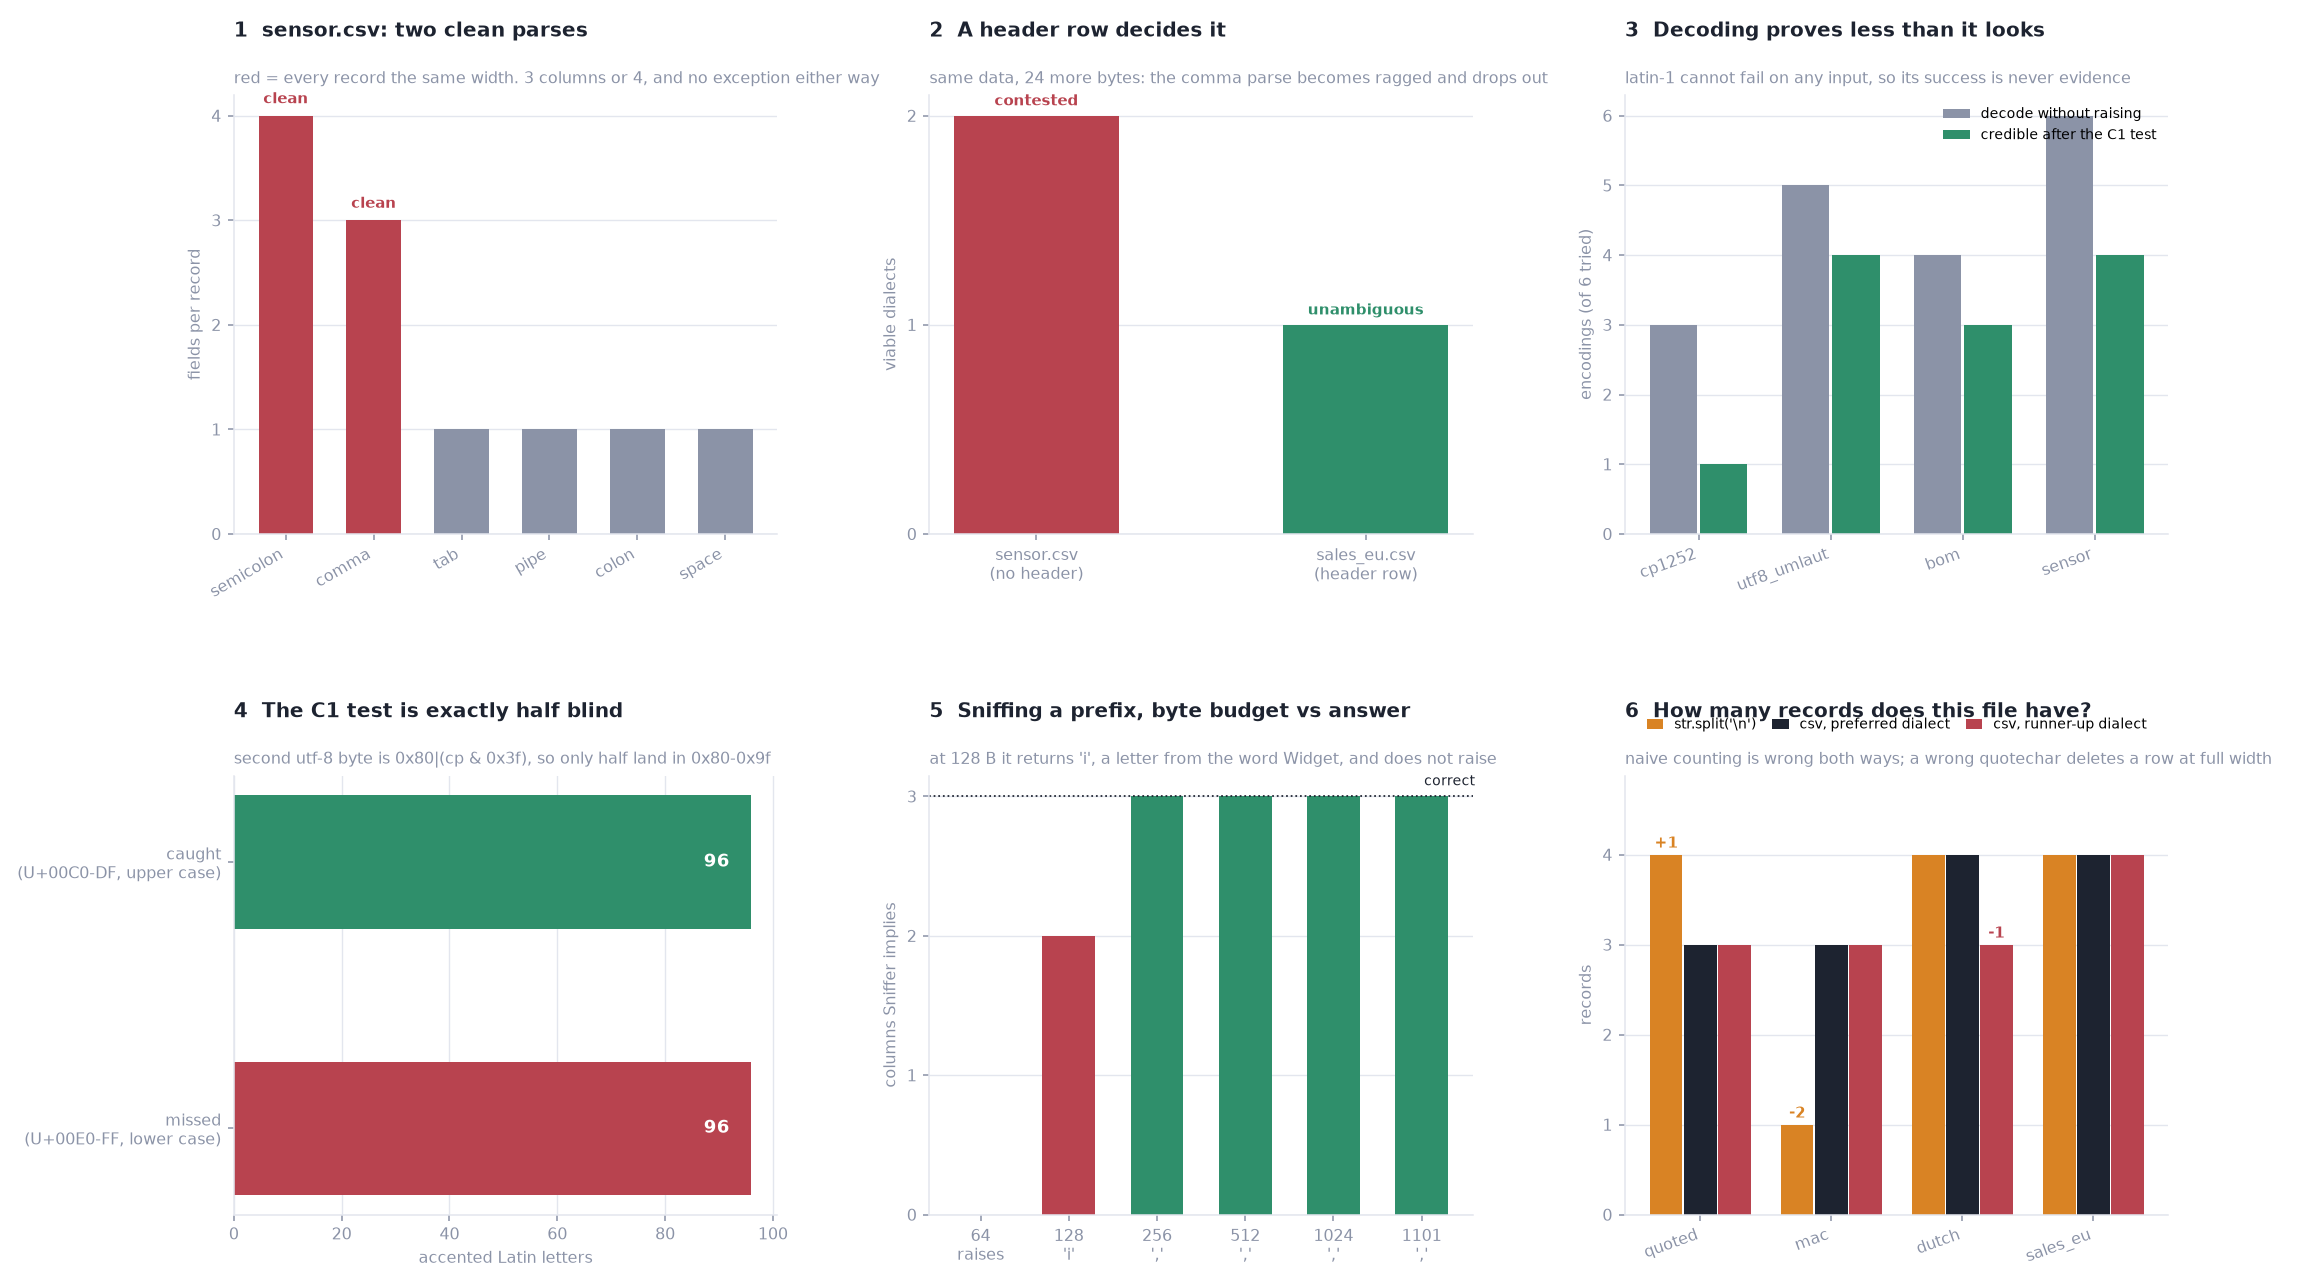

In [13]:
import matplotlib.pyplot as plt
from IPython.display import Image, display
import make_chart as mc

fig, axes = plt.subplots(2, 3, figsize=(16.5, 9.2))
fig.patch.set_facecolor("white")
panels = [mc.panel_candidates, mc.panel_header_tie, mc.panel_encoding,
          mc.panel_c1_coverage, mc.panel_sample_size, mc.panel_line_counts]
for ax, fn in zip(axes.ravel(), panels):
    ax.set_facecolor("white")
    fn(ax)
fig.tight_layout()
fig.subplots_adjust(hspace=0.55, wspace=0.28)
fig.savefig("sniff_audit_nb.png", dpi=140, facecolor="white")
plt.close(fig)
display(Image("sniff_audit_nb.png"))


## The ledger

Ten failure modes across eleven sample files. Nine of the ten produce a plausible
answer with no exception, and all ten are reproducible - re-running the load gives
the same wrong number, so a reconciliation against yesterday agrees.

In [14]:
evidence.ledger()



9. The ledger
failure mode                      sample            effect                      raises?   
------------------------------------------------------------------------------
two clean parses, 3 vs 4 cols     sensor.csv        wrong column count          silent    
utf-8 read as latin-1             utf8_umlaut.csv   AusfÃ¼hrung in every row    silent    
latin-1 read for a cp1252 file    cp1252.csv        C1 controls in the text     silent    
BOM kept as a name character      bom.csv           KeyError on a visible column  raises late
numeric header read as data       years.csv         col 0 inflated by 2019      silent    
text data row read as header      alltext.csv       one row lost, names wrong   silent    
apostrophe read as a quotechar    dutch.csv         1 of 4 records merged away  silent    
prefix sniff picks 'i'            late.csv          1-column frame              silent    
bare \r line ending               mac.csv           3 records counted as 1      sile

## Auditing one file

`audit()` returns everything the bytes determine and everything they do not, in
one object. `decided` is `True` only when the delimiter is unambiguous, the
encoding is settled, and the header question is answerable.

In [15]:
for name, raw in sniff.sample_files().items():
    a = sniff.audit(raw, name)
    flag = "OK " if a.decided else "?? "
    print("{0}{1:<18} {2:<13} enc={3:<10} header={4}".format(
        flag, name, a.delimiter.status, a.encoding.verdict,
        a.header.status if a.header else "-"))
    for note in a.notes:
        print("      - " + note[:96])


?? sensor.csv         contested     enc=utf-8      header=undetermined
      - success proves nothing for: cp1252 (only 5 of 256 byte values are undefined (81 8d 8f 90 9d)); l
      - 6 encodings decode these bytes to 2 different strings, none raising
      - csv.Sniffer.has_header() answers False where the file does not say
      - no field in this file is quoted, so quote="'", quote=none is untested here - it parses identical
      - CONTESTED: 2 dialects parse the file cleanly, implying 3 or 4 column(s) - the bytes do not choos
OK sales_eu.csv       unambiguous   enc=utf-8      header=header
      - success proves nothing for: cp1252 (only 5 of 256 byte values are undefined (81 8d 8f 90 9d)); l
      - 6 encodings decode these bytes to 2 different strings, none raising
      - no field in this file is quoted, so quote="'", quote=none is untested here - it parses identical
OK cp1252.csv         unambiguous   enc=cp1252     header=header
      - success proves nothing for: cp1252 (onl

## Try your own

Paste a few lines of a real export below. The interesting cases are European
exports, anything from a spreadsheet on a Mac, and anything with a header made of
dates or years.

In [16]:
text = '''region;units;price
north;12;1,50
south;8;2,25
'''

v = sniff.classify_delimiter(text)
print("status :", v.status)
print("reason :", v.reason)
for s in v.viable:
    print("   viable:", s.label, "->", s.records, "records x", s.modal, "fields")
print("Sniffer:", repr(sniff.sniffer_says(text)))

rows = [r for r in sniff.parse(text, v.preferred.delimiter, v.preferred.quotechar) if r]
h = sniff.classify_header(rows, text)
print("header :", h.status, "-", h.reason)

# And on bytes, to exercise the encoding probe:
# r = sniff.probe_encoding(open("your_file.csv", "rb").read())
# print(r.verdict, "|", r.reason)


status : unambiguous
reason : exactly one dialect parses the file cleanly
   viable: semicolon / quote='"' -> 3 records x 3 fields
Sniffer: ';'
header : header - 2 column(s) are text in row 0 and non-text below: 1, 2


## What to take from this

- **Enumerate, then judge.** A detector that returns one answer cannot tell you it
  had two. Enumerating candidates costs one parse per candidate and buys a verdict
  you can act on.
- **Asymmetric evidence is normal.** A failed decode is a fact; a successful one
  often is not. A text-over-numeric first row proves a header; a matching first row
  proves nothing. Build the API around which direction is decidable.
- **Name the tie-breaks.** Column count, then record count, then delimiter order
  are preferences, not detections. They belong in the output, not in a comment.
- **Report the blind spot with the test.** The C1 heuristic catches exactly half of
  accented letters, and which half is derivable from the encoding, not measured.
- **Sample size is part of the answer.** Any prefix-based detection should report
  the prefix it used.

Reproduce everything here:

```bash
python3 test_sniff.py   # 46 tests over the core
python3 evidence.py     # every table above
python3 make_chart.py   # the six-panel figure
```

Part of [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) - Day 142, Data Engineering Pro.
The Streamlit version puts the verdict first and the parsed table last, so an
undecidable file cannot be mistaken for a decided one:

```bash
pip install -r requirements.txt
streamlit run app.py
```
